In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\dines\Downloads\Business_Analytics\clean_airline_dataset.csv")
print("Initial Shape:", df.shape)
df.head()

Initial Shape: (2099, 28)


,Gender,Age,Occupation,Purpose_of_Travel,Travel_Frequency,Travel_Class,Flight_Preference,Booking_Mode,Influencing_Factors,Airline_Last_Flown,...,family_visit,education,medical,others,indigo,spicejet,vistara,air_india,akasa,airline_count
0,man,35-44,working professional,others,4-6 flights,business,prefer 1-stop if cheaper,other,['punctuality'],other;,...,0,0,0,0,1,0,0,0,0,1
1,man,45-60,government employee,others,7-10 flights,first class,prefer 1-stop if cheaper,other,['brand reputation'],indigo;,...,0,0,0,1,1,0,0,0,0,1
2,woman,19-24,student,leisure/vacation;family visit;education,1 flight,economy,direct flight only,"third party website (e.g makemytrip, goibibo)","['ticket price', 'brand reputation', 'safety r...",indigo,...,1,1,0,0,1,0,0,0,0,1
3,man,19-24,student,others;,1 flight,economy,direct flight only,airline website/app,"['seat comfort', 'ticket price', 'in flight se...",indigo;air india;other;,...,1,0,0,0,1,0,0,0,0,1
4,man,35-44,working professional,business,7-10 flights,first class,prefer 1-stop if cheaper,travel agent,"['brand reputation', 'safety rating', 'in flig...",other;,...,0,0,0,0,0,0,0,1,0,1


In [2]:
drop_cols = [
    "Airline_Last_Flown",
    "Purpose_List",
    "airline_count",
    "indigo",
    "spicejet",
    "vistara",
    "air_india",
    "akasa"
]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

print("Shape after dropping leakage columns:", df.shape)

Shape after dropping leakage columns: (2099, 20)


In [3]:
def parse_multi(val):
    if pd.isna(val):
        return []
    
    val = str(val).strip()
    
    if val.startswith("[") and val.endswith("]"):
        try:
            parsed = ast.literal_eval(val)
            return [str(x).strip().lower().replace(" ", "_") for x in parsed]
        except:
            return []
    
    return [val.lower().replace(" ", "_")]

In [4]:
multi_cols = ["Influencing_Factors", "Reward_Preference", "Inflight_Priority"]

for col in multi_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_multi)
        
        mlb = MultiLabelBinarizer()
        encoded = mlb.fit_transform(df[col])
        
        encoded_df = pd.DataFrame(
            encoded,
            columns=[f"{col}_{cls}" for cls in mlb.classes_],
            index=df.index
        )
        
        df = pd.concat([df, encoded_df], axis=1)
        df.drop(columns=[col], inplace=True)

print("Shape after multi-label encoding:", df.shape)

Shape after multi-label encoding: (2099, 37)


In [5]:
categorical_cols = df.select_dtypes(include="object").columns

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after full encoding:", df_encoded.shape)

Shape after full encoding: (2099, 107)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print("Scaled dataset shape:", X_scaled.shape)

Scaled dataset shape: (2099, 107)


In [7]:
X_scaled.to_csv("airline_segmentation_ready.csv", index=False)
print("Segmentation dataset saved successfully ✅")

Segmentation dataset saved successfully ✅


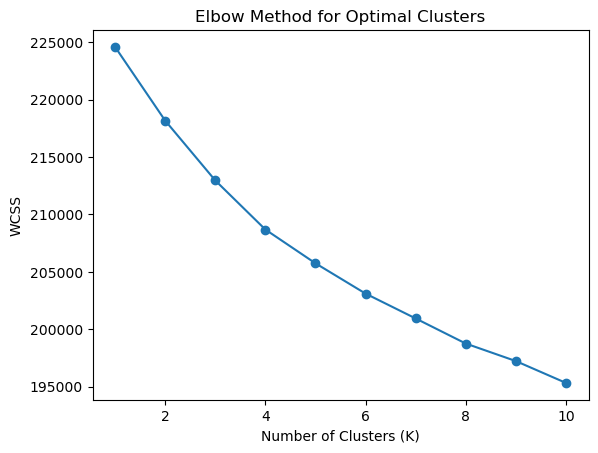

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df_encoded["Cluster"] = clusters

In [10]:
df_encoded["Cluster"].value_counts()

Cluster
3    889
0    787
2    260
1    163
Name: count, dtype: int64

In [11]:
cluster_profile = df_encoded.groupby("Cluster").mean()

cluster_profile

,business,leisure,family_visit,education,medical,others,Influencing_Factors_brand_reputation,Influencing_Factors_free_food,Influencing_Factors_in_flight_service_quality,Influencing_Factors_loyalty_programs,...,"Booking_Mode_third party website (e.g makemytrip, goibibo)",Booking_Mode_travel agent,Price_Sensitivity_somewhat sensitive,Price_Sensitivity_very sensitive,Loyalty_Program_planning to join,Loyalty_Program_yes,Schedule_Preference_early morning,Schedule_Preference_evening,Schedule_Preference_late night,Schedule_Preference_no preference
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.008895,0.308767,0.219822,0.252859,0.000000,0.212198,0.269377,0.297332,0.290978,0.260483,...,0.186785,0.232529,0.059720,0.607370,0.000000,0.400254,0.184244,0.191868,0.208386,0.195680
1,0.116564,0.588957,0.527607,0.453988,0.012270,0.000000,0.226994,0.128834,0.490798,0.073620,...,0.325153,0.061350,0.515337,0.417178,0.030675,0.110429,0.233129,0.220859,0.165644,0.214724
2,0.023077,0.461538,0.330769,0.000000,0.246154,0.184615,0.265385,0.296154,0.338462,0.253846,...,0.196154,0.223077,0.084615,0.669231,0.003846,0.338462,0.200000,0.192308,0.226923,0.169231
3,0.788526,0.101237,0.066367,0.000000,0.000000,0.051744,0.260967,0.259843,0.316085,0.275591,...,0.231721,0.201350,0.059618,0.699663,0.000000,0.304837,0.212598,0.211474,0.177728,0.199100


In [12]:
"""
🧠 Customer Segmentation Interpretation
🔵 Cluster 0 — Multi-Purpose Price-Sensitive Travelers

Key signals:

Leisure: 30%

Education: 25%

Family visit: 22%

Very price sensitive: 60%

Loyalty program: 40%

Influencing factors:

Brand reputation

Service quality

Loyalty programs

Interpretation

These travelers:

Travel mainly for leisure, education, and family visits

Are highly price sensitive

Still value brand trust and service quality

Have moderate loyalty interest

Segment Name

Budget Multi-Purpose Travelers

Strategy

Airlines should target them with:

Discount campaigns

Student fares

Loyalty sign-up promotions

🟢 Cluster 1 — Leisure Family Travelers

Key signals:

Leisure: 59%

Family visit: 53%

Education: 45%

Loyalty program: 11% (low)

Price sensitivity:

Somewhat sensitive: 51%

Very sensitive: 41%

Influencing factors:

Service quality (49%) — very high

Interpretation

These travelers:

Fly mainly for vacations and family trips

Care strongly about service quality

Are moderately price sensitive

Do not strongly engage with loyalty programs

Segment Name

Leisure Experience Seekers

Strategy

Airlines should focus on:

Family travel packages

Vacation promotions

Service quality marketing

🟠 Cluster 2 — Medical / Occasional Travelers

Key signals:

Medical travel: 25%

Leisure: 46%

Family visit: 33%

Very price sensitive: 67%

Influencing factors:

Service quality

Free food

Brand reputation

Interpretation

These travelers:

Travel occasionally for medical reasons or family

Are extremely price sensitive

Prefer comfort and service reliability

Segment Name

Occasional Essential Travelers

Strategy

Airlines can target them with:

Flexible ticket policies

Medical travel discounts

Comfort-focused services

🔴 Cluster 3 — Business Travelers

Key signals:

Business travel: 79%

Very price sensitive: 70%

Loyalty program: 30%

Influencing factors:

Service quality

Loyalty programs

Brand reputation

Interpretation

These travelers:

Travel primarily for business

Travel frequently

Care about punctuality and service

Engage moderately with loyalty programs

Segment Name

Frequent Business Travelers

Strategy

Airlines should focus on:

Corporate loyalty programs

Business class upgrades

Priority services


"""

'\n🧠 Customer Segmentation Interpretation\n🔵 Cluster 0 — Multi-Purpose Price-Sensitive Travelers\n\nKey signals:\n\nLeisure: 30%\n\nEducation: 25%\n\nFamily visit: 22%\n\nVery price sensitive: 60%\n\nLoyalty program: 40%\n\nInfluencing factors:\n\nBrand reputation\n\nService quality\n\nLoyalty programs\n\nInterpretation\n\nThese travelers:\n\nTravel mainly for leisure, education, and family visits\n\nAre highly price sensitive\n\nStill value brand trust and service quality\n\nHave moderate loyalty interest\n\nSegment Name\n\nBudget Multi-Purpose Travelers\n\nStrategy\n\nAirlines should target them with:\n\nDiscount campaigns\n\nStudent fares\n\nLoyalty sign-up promotions\n\n🟢 Cluster 1 — Leisure Family Travelers\n\nKey signals:\n\nLeisure: 59%\n\nFamily visit: 53%\n\nEducation: 45%\n\nLoyalty program: 11% (low)\n\nPrice sensitivity:\n\nSomewhat sensitive: 51%\n\nVery sensitive: 41%\n\nInfluencing factors:\n\nService quality (49%) — very high\n\nInterpretation\n\nThese travelers:\n\nFly

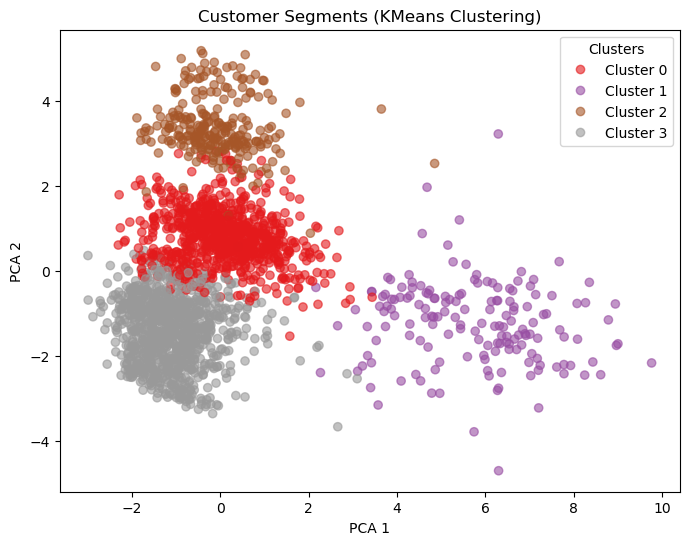

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters,
    cmap="Set1",
    alpha=0.6
)

plt.title("Customer Segments (KMeans Clustering)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Cluster 0","Cluster 1","Cluster 2","Cluster 3"],
           title="Clusters", loc="upper right")

plt.show()

C:\Users\dines\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


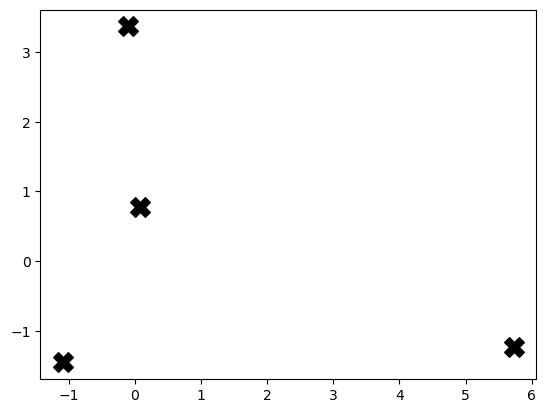

In [14]:
centroids = kmeans.cluster_centers_

centroids_pca = pca.transform(centroids)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    c="black",
    marker="X",
    s=200,
    label="Centroids"
)

In [ ]:
"""📊 What the Axes Represent

Your axes are:

PCA 1 (horizontal)
PCA 2 (vertical)

These come from Principal Component Analysis (PCA).

PCA compresses many features (your ~100 encoded variables) into two major directions of variation.

So:

PCA 1

Represents the strongest behavioral difference between customers.

In airline datasets this usually captures things like:

Travel purpose

Travel frequency

Travel class

booking mode

The fact that one cluster is far right suggests those customers behave very differently.

Most likely frequent/business travelers.

PCA 2

Represents the second strongest behavioral difference.

This often reflects:

service expectations

comfort preferences

influencing factors

Clusters separated vertically likely differ in service vs price orientation.

🧠 Interpreting Each Cluster

From the visual layout:

🟣 Cluster 1 (Purple — Right Side)

Position:

Far right on PCA1

Very separated

Meaning:
These customers behave very differently from others.

Likely characteristics:

Business travel

higher travel frequency

loyalty program usage

possibly business class

Segment

Frequent Business Travelers

Strategy:

corporate loyalty programs

business class offers

punctuality focus

🔴 Cluster 0 (Red — Center Left)

Position:

middle of PCA1

moderate PCA2

This is the largest central group.

Likely characteristics:

mixed travel purposes

moderate price sensitivity

occasional travelers

Segment

Budget Multi-Purpose Travelers

Strategy:

discount campaigns

loyalty sign-ups

🟤 Cluster 2 (Brown — Top)

Position:

high PCA2

moderate PCA1

These customers are separated vertically.

This usually indicates:

strong service expectations

comfort priorities

brand reputation importance

Segment

Service-Focused Travelers

Strategy:

premium experience marketing

service quality branding

⚫ Cluster 3 (Grey — Bottom)

Position:

low PCA2

low PCA1

These are likely:

very price sensitive

leisure / family travel

low loyalty engagement

Segment

Price-Sensitive Leisure Travelers

Strategy:

budget fares

promotional pricing

seasonal offers

📊 Final Cluster Interpretation
Cluster	Color	Segment	Key Traits
0	Red	Budget Multi-Purpose Travelers	mixed purpose, moderate price sensitivity
1	Purple	Frequent Business Travelers	high frequency, distinct behavior
2	Brown	Service-Focused Travelers	value service & comfort
3	Grey	Price-Sensitive Leisure Travelers	budget oriented """